Training on cpu...
Step 0: Train Loss 4.5039 | Val Loss 4.4585
Step 300: Train Loss 2.6036 | Val Loss 2.5738
Step 600: Train Loss 2.4676 | Val Loss 2.4517
Step 900: Train Loss 2.4569 | Val Loss 2.5121
Step 1200: Train Loss 2.4719 | Val Loss 2.4811
Step 1500: Train Loss 2.4239 | Val Loss 2.4853
Step 1800: Train Loss 2.4624 | Val Loss 2.4751
Step 2100: Train Loss 2.4763 | Val Loss 2.4855
Step 2400: Train Loss 2.4586 | Val Loss 2.4628
Step 2700: Train Loss 2.4624 | Val Loss 2.4984
Step 2999: Train Loss 2.4370 | Val Loss 2.5492


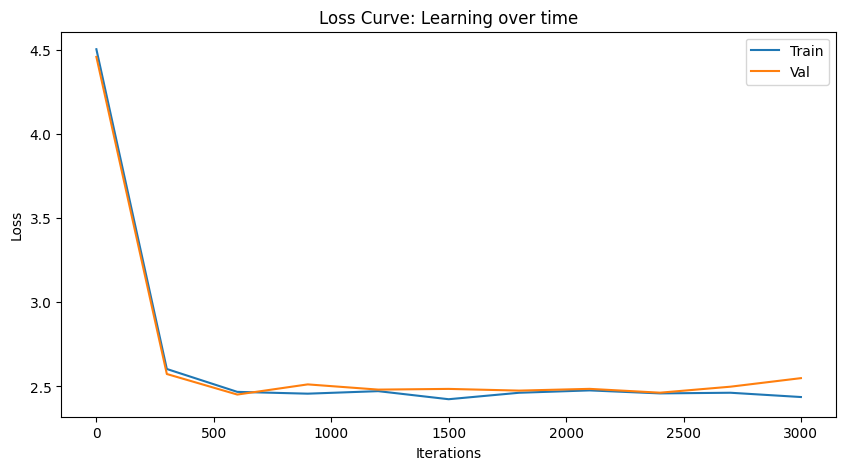


--- Generation Evolution ---

[Step 0]:

qGKTlzmAu&pH!JSdcfLcNAXRkvXTM!dNs,qoBhAvM VcgHVavf3zJevObMvSP'rGp;ak&FaeO;MMphIJJUiZAGtVpmnKUJKJpngu

[Step 300]:

Ile; w y l; ld my ce a h 'shy'scxaier no blrinLthomaurilees he wh


L'onerwoucourewhand e theay re v

[Step 600]:


HENGERnenderd he u
To wasitouscefulthare, f is te h pe.
MOLUSOPaUCHOUMENCEK:
S:


Myo airesp my m a

[Step 900]:

AOLon p Fr the ouguniroullesthe tell chas,

Andin, iorcwitourste ar ofangs fd mifend benthe disouce.

[Step 1200]:


OVINe,
Fanusve sond y attheito a
MELo bedbe s s, ENE:
PENAnthem.
Be al.
BUKI ratilounost an ey ntum

[Step 1500]:

LAansw I OPren do at y Su, ker, h a tr.


RGLI'XIESUS:
rr'sele ve etowiren ke
LINCI o f te f wh f me

[Step 1800]:


I S: heng
Whall olou he ant me, t!
S:

Tin to;
STofrtir ve quin t asbr so wilo knf b.
Nu bou is d d

[Step 2100]:

ERKI anghr susin.
G we' enBupa s tilire,
Geare mioue ano owhenspouceild,
AO isutheas.

Whandor wad, 

[Step 2400]:

Theanto n th bod qusel har ds pou

In [5]:

import torch
import torch.nn as nn
from torch.nn import functional as F
import requests
import os
import matplotlib.pyplot as plt

# --- 1. DATA AND HYPERPARAMETERS ---
batch_size = 32
block_size = 64 # Context length
max_iters = 3000
eval_interval = 300
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_embd = 128

# Download and Load Data
filename = 'input.txt'
if not os.path.exists(filename):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    with open(filename, 'wb') as f:
        f.write(requests.get(url).content)

with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()

# Tokenization
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = { ch:i for i,ch in enumerate(chars) }
int_to_char = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [char_to_int[c] for c in s]
decode = lambda l: ''.join([int_to_char[i] for i in l])

# Train/Val split
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

# --- 2. MODEL DEFINITION ---
class TinyLLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

# --- 3. TRAINING AND ANALYSIS LOOP ---
model = TinyLLM(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_loss_history = []
val_loss_history = []
evolution_samples = {}

print(f"Training on {device}...")

for iter in range(max_iters):
    # Fetch batch
    ix = torch.randint(len(train_data) - block_size, (batch_size,))
    x = torch.stack([train_data[i:i+block_size] for i in ix]).to(device)
    y = torch.stack([train_data[i+1:i+block_size+1] for i in ix]).to(device)

    # Forward/Backward
    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # Evaluation Step
    if iter % eval_interval == 0 or iter == max_iters - 1:
        model.eval()
        with torch.no_grad():
            vix = torch.randint(len(val_data) - block_size, (batch_size,))
            vx = torch.stack([val_data[i:i+block_size] for i in vix]).to(device)
            vy = torch.stack([val_data[i+1:i+block_size+1] for i in vix]).to(device)
            _, v_loss = model(vx, vy)

            train_loss_history.append(loss.item())
            val_loss_history.append(v_loss.item())

            # Record generation evolution
            context = torch.zeros((1, 1), dtype=torch.long, device=device)
            evolution_samples[iter] = decode(model.generate(context, max_new_tokens=100)[0].tolist())

            print(f"Step {iter}: Train Loss {loss.item():.4f} | Val Loss {v_loss.item():.4f}")
        model.train()

# --- 4. VISUALIZATION ---
# Plot Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(train_loss_history)*eval_interval, eval_interval), train_loss_history, label='Train')
plt.plot(range(0, len(val_loss_history)*eval_interval, eval_interval), val_loss_history, label='Val')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve: Learning over time')
plt.legend()
plt.show()

# Show Text Evolution
print("\n--- Generation Evolution ---")
for step in sorted(evolution_samples.keys()):
    print(f"\n[Step {step}]:\n{evolution_samples[step]}")

In [6]:
context = torch.tensor(encode("ROMEO:"), dtype=torch.long, device=device).view(1, -1)
print(decode(model.generate(context, max_new_tokens=100)[0].tolist()))

ROMEO:
Youloute Yoon bute, sthelnd hifr d hathor k t

Whid nd.
FLYBETinourswan ce' g ghis?
JUWhe win OThim


In [7]:
context = torch.tensor(encode("HI:"), dtype=torch.long, device=device).view(1, -1)
print(decode(model.generate(context, max_new_tokens=100)[0].tolist()))

HI:
Sllie, CO, ankn luthil mpland! w, iong
NTIIIRToray hinchen'shenat?

WAng ar
Th
en ney IORE:
Tothehe


In [8]:
context = torch.tensor(encode("Nishita:"), dtype=torch.long, device=device).view(1, -1)
print(decode(model.generate(context, max_new_tokens=100)[0].tolist()))

Nishita: at s 'sthe wn tk, morst ioourevengh p ak fof.
AMh bu anoumal,
ARIZQU:-mor blalewica ase t, werulind


# **Google common words**

In [18]:

import torch
import torch.nn as nn
from torch.nn import functional as F
import requests
import os

# --- 1. DATA PREPARATION ---
# Using a list of common English words to learn modern spelling
filename = 'words.txt'
if not os.path.exists(filename):
    url = "https://raw.githubusercontent.com/first20hours/google-10000-english/master/google-10000-english.txt"
    with open(filename, 'wb') as f:
        f.write(requests.get(url).content)

with open(filename, 'r') as f:
    text = f.read().lower() # Lowercase to make learning easier

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = { ch:i for i,ch in enumerate(chars) }
int_to_char = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [char_to_int[c] for c in s]
decode = lambda l: ''.join([int_to_char[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 2. SIMPLE MODEL ARCHITECTURE ---
class TinyLLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, 128)
        self.position_embedding_table = nn.Embedding(64, 128)
        self.lm_head = nn.Linear(128, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -64:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

model = TinyLLM(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# --- 3. TRAINING ---
print("Training on English words...")
for iter in range(5000): # Increased iterations to learn spelling
    ix = torch.randint(len(data) - 64, (32,))
    x = torch.stack([data[i:i+64] for i in ix]).to(device)
    y = torch.stack([data[i+1:i+65] for i in ix]).to(device)

    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iter % 500 == 0:
        print(f"step {iter}: loss {loss.item():.4f}")



Training on English words...
step 0: loss 3.5631
step 500: loss 2.5367
step 1000: loss 2.4665
step 1500: loss 2.5031
step 2000: loss 2.5017
step 2500: loss 2.4761
step 3000: loss 2.4990
step 3500: loss 2.5193
step 4000: loss 2.5002
step 4500: loss 2.4878


In [24]:
# --- 4. PREDICTION TEST ---
print("\n--- Testing Prediction ---")
prompt = "he"
context = torch.tensor(encode(prompt), dtype=torch.long, device=device).view(1, -1)
# Generate just 1 more character to see if it predicts 'o'
prediction = decode(model.generate(context, max_new_tokens=1)[0].tolist())
print(f"Input: {prompt} -> Output: {prediction}")


--- Testing Prediction ---
Input: he -> Output: hes
